**Title:** DSC 680: Milestone Three
**Author:** William Anderson  
**Date:** 2 July 2026  
**Description:** Milestone Three

             Player    Salary  Year Pos  Age Team   G  GS    MP   FG  ...  \
0       Kobe Bryant  23034375  2010  SG   31  LAL  73  73  38.8  9.8  ...   
1   Jermaine O'Neal  23016000  2010   C   31  MIA  70  70  28.4  5.6  ...   
2     Tracy McGrady  22843124  2010  SG   30  NYK  30  24  22.4  3.0  ...   
3        Tim Duncan  22183220  2010   C   33  SAS  78  77  31.3  7.2  ...   
4  Shaquille O'Neal  21000000  2010   C   37  CLE  53  53  23.4  4.9  ...   

     FT%  ORB  DRB   TRB  AST  STL  BLK  TOV   PF   PTS  
0  0.811  1.1  4.3   5.4  5.0  1.5  0.3  3.2  2.6  27.0  
1  0.720  1.8  5.2   6.9  1.3  0.4  1.4  1.8  3.0  13.6  
2  0.746  0.7  2.4   3.1  3.3  0.5  0.5  1.5  1.3   8.2  
3  0.725  2.8  7.3  10.1  3.2  0.6  1.5  1.8  1.9  17.9  
4  0.496  1.8  4.9   6.7  1.5  0.3  1.2  2.0  3.2  12.0  

[5 rows x 31 columns]
Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA

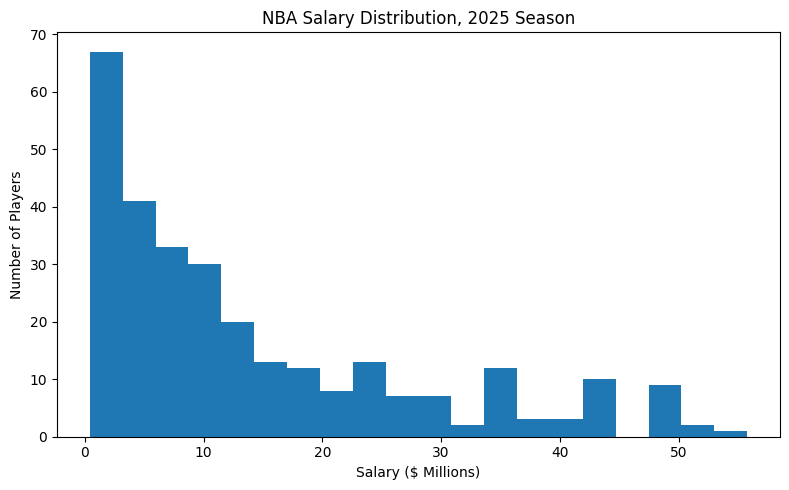

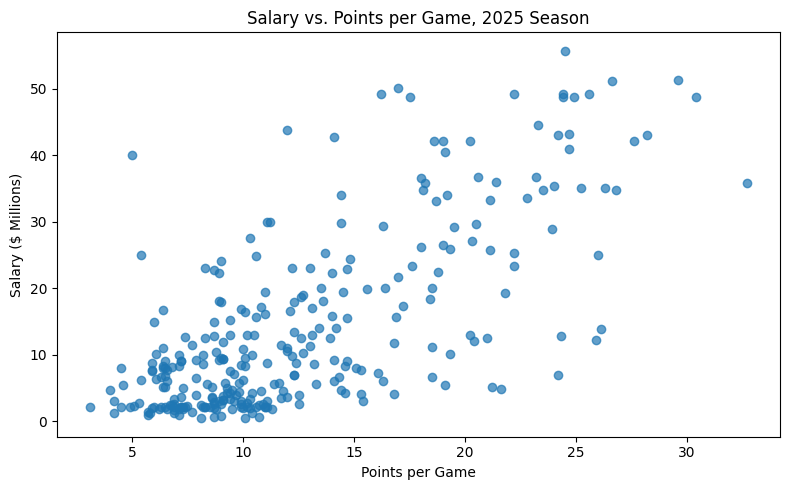

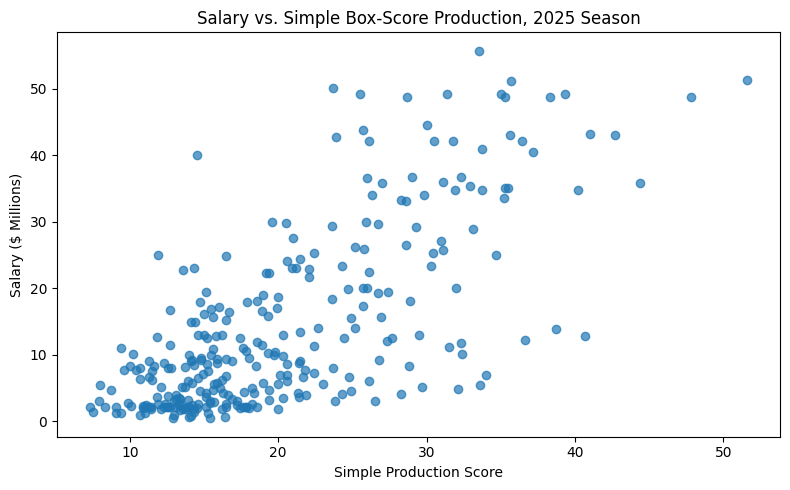

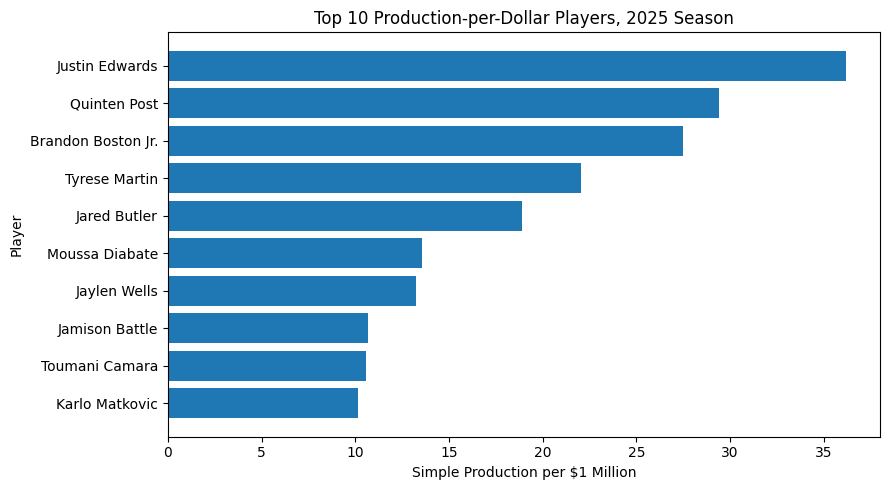

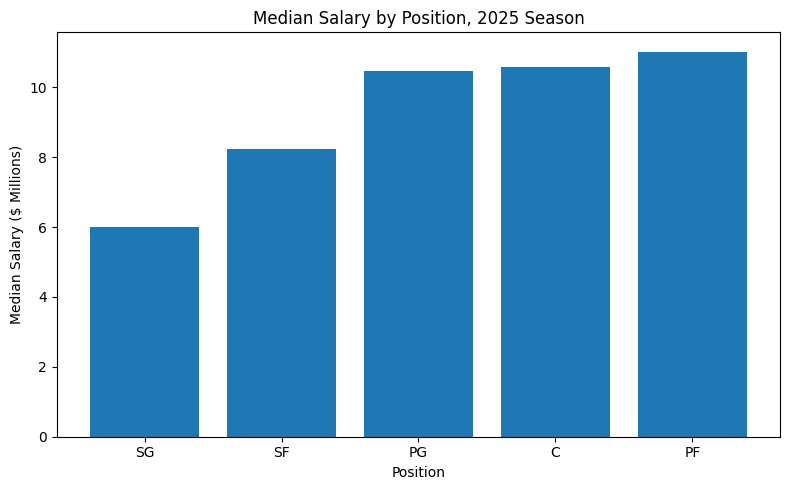

Model test MAE: $3.94M
Model test R² on log salary: 0.467


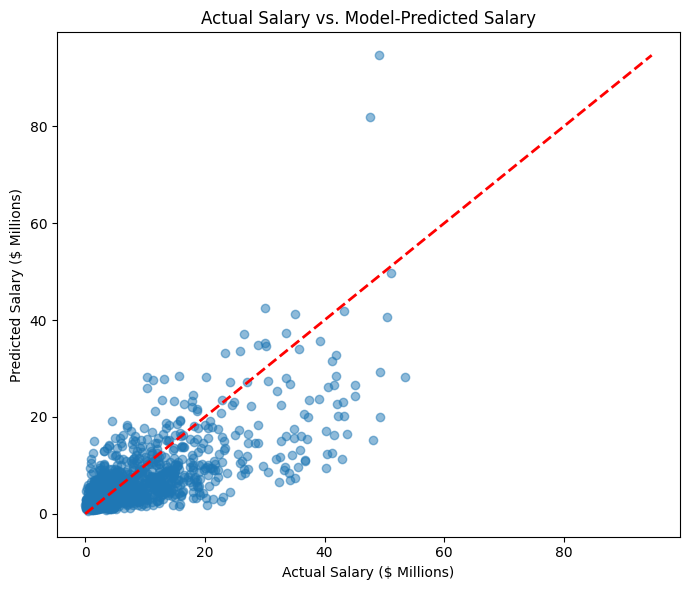

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from zipfile import ZipFile

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

#1. Load data

csv_path = Path(r"C:\BU MS DS\DSC680 - Applied Data Science\NBA Player Stats and Salaries_2010-2025.csv")

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

#2. basic eda/cleaning

work = df.copy()

work["Salary_Millions"] = work["Salary"] / 1_000_000

# The Kaggle CSV does not include Win Shares, BPM, or VORP.
# So this creates a simple, explainable box-score production metric.
work["Simple_Production"] = (
    work["PTS"].fillna(0)
    + work["TRB"].fillna(0)
    + work["AST"].fillna(0)
    + work["STL"].fillna(0)
    + work["BLK"].fillna(0)
    - work["TOV"].fillna(0)
)

work["Production_per_1M"] = (
    work["Simple_Production"] / work["Salary_Millions"].replace(0, np.nan)
)


#3. filter date to latest szn

latest_year = int(work["Year"].max())

latest = work[
    (work["Year"] == latest_year)
    & (work["G"] >= 40)
    & (work["MP"] >= 15)
    & (work["Salary_Millions"] > 0)
].copy()

print(f"Latest season used: {latest_year}")
print(f"Rows after filtering: {len(latest)}")


#4. output

out_dir = Path(r"C:\BU MS DS\DSC680 - Applied Data Science\nba_salary_value_visuals")
out_dir.mkdir(exist_ok=True)


# =========================
# Figure 1: Salary distribution
# =========================

plt.figure(figsize=(8, 5))
plt.hist(latest["Salary_Millions"].dropna(), bins=20)
plt.title(f"NBA Salary Distribution, {latest_year} Season")
plt.xlabel("Salary ($ Millions)")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.savefig(out_dir / "figure1_salary_distribution.png", dpi=200)
plt.show()


# =========================
# Figure 2: Salary vs. PPG
# =========================

plt.figure(figsize=(8, 5))
plt.scatter(latest["PTS"], latest["Salary_Millions"], alpha=0.7)
plt.title(f"Salary vs. Points per Game, {latest_year} Season")
plt.xlabel("Points per Game")
plt.ylabel("Salary ($ Millions)")
plt.tight_layout()
plt.savefig(out_dir / "figure2_salary_vs_points.png", dpi=200)
plt.show()


# =========================
# Figure 3: Salary vs. Simple Production
# =========================

plt.figure(figsize=(8, 5))
plt.scatter(latest["Simple_Production"], latest["Salary_Millions"], alpha=0.7)
plt.title(f"Salary vs. Simple Box-Score Production, {latest_year} Season")
plt.xlabel("Simple Production Score")
plt.ylabel("Salary ($ Millions)")
plt.tight_layout()
plt.savefig(out_dir / "figure3_salary_vs_simple_production.png", dpi=200)
plt.show()


# =========================
# Figure 4: Top 10 Production-per-Dollar Players
# =========================

top_value = (
    latest.sort_values("Production_per_1M", ascending=False)
    .head(10)
    .sort_values("Production_per_1M")
)

plt.figure(figsize=(9, 5))
plt.barh(top_value["Player"], top_value["Production_per_1M"])
plt.title(f"Top 10 Production-per-Dollar Players, {latest_year} Season")
plt.xlabel("Simple Production per $1 Million")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig(out_dir / "figure4_top_production_per_dollar.png", dpi=200)
plt.show()


# =========================
# Figure 5: Median Salary by Position
# =========================

pos_salary = (
    latest.groupby("Pos", as_index=False)["Salary_Millions"]
    .median()
    .sort_values("Salary_Millions")
)

plt.figure(figsize=(8, 5))
plt.bar(pos_salary["Pos"], pos_salary["Salary_Millions"])
plt.title(f"Median Salary by Position, {latest_year} Season")
plt.xlabel("Position")
plt.ylabel("Median Salary ($ Millions)")
plt.tight_layout()
plt.savefig(out_dir / "figure5_median_salary_by_position.png", dpi=200)
plt.show()


# =========================
# 5. Simple salary prediction model
# =========================

model_cols = [
    "Age", "G", "GS", "MP", "PTS", "TRB", "AST",
    "STL", "BLK", "TOV", "eFG%", "Pos"
]

model_df = work.dropna(subset=model_cols + ["Salary"]).copy()

model_df = model_df[
    (model_df["G"] >= 20)
    & (model_df["MP"] >= 10)
    & (model_df["Salary"] > 0)
].copy()

#log salary bc of skewness of salaries
model_df["Log_Salary"] = np.log1p(model_df["Salary"])

X = model_df[model_cols]
y = model_df["Log_Salary"]

numeric_features = [col for col in model_cols if col != "Pos"]
categorical_features = ["Pos"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25
)

model.fit(X_train, y_train)

pred_log = model.predict(X_test)

actual_salary = np.expm1(y_test)
pred_salary = np.expm1(pred_log)

mae_millions = mean_absolute_error(actual_salary, pred_salary) / 1_000_000
r2 = r2_score(y_test, pred_log)

print(f"Model test MAE: ${mae_millions:.2f}M")
print(f"Model test R² on log salary: {r2:.3f}")


# =========================
# Figure 6: Actual vs. Predicted Salary
# =========================

plt.figure(figsize=(7, 6))
plt.scatter(actual_salary / 1_000_000, pred_salary / 1_000_000, alpha=0.5)

max_axis = max(actual_salary.max(), pred_salary.max()) / 1_000_000
plt.plot([0, max_axis], [0, max_axis], linestyle="--", color="red", linewidth=2)

plt.title("Actual Salary vs. Model-Predicted Salary")
plt.xlabel("Actual Salary ($ Millions)")
plt.ylabel("Predicted Salary ($ Millions)")
plt.tight_layout()
plt.savefig(out_dir / "figure6_actual_vs_predicted_salary.png", dpi=200)
plt.show()


#to note - relatively no updates were needed from milestone two to milestone three. all that was done was essentially a few spot checks + moving the plots to the deck/powerpoint presentation.

